In [76]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri
from pathlib import Path, PosixPath

## Load participant data and meta files 

In [77]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)

def get_sex_cond(tgt_name, df_w_transcripts=df_w_transcripts):
    if tgt_name is None:
        return None
    return df_w_transcripts[df_w_transcripts["targ_src_stem"] == tgt_name].sex_cond.item()



In [78]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localize_speech_in_elevation_w_distractor_v00/')
part_results = sorted(list(path_to_parts.glob("part*")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localize_speech_in_elevation_w_distractor_v00/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))
array_manifests = sorted(list(path_to_meta_data.glob("*trial_dict.pkl")))
                         
# get label to location map
with open("array_label_to_loc_dict.pkl", 'rb') as f:
    label_to_loc_map = pickle.load(f)

with open("array_loc_to_label_dict.pkl", 'rb') as f:
    loc_to_label_dict = pickle.load(f)

label_to_loc_map = {label: [loc[0], loc[1]] for label, loc in label_to_loc_map.items()}
# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file

array_manifest_dict = {}    
for array_manifest in array_manifests:
    if 'pilot' in array_manifest.parent.stem:
        part_name = "pilot_" + "_".join(array_manifest.stem.split('_')[:2])

    else:
        part_name = "_".join(array_manifest.stem.split('_')[:2])
    array_manifest_dict[part_name] = array_manifest

incomplete_parts = ["participant_009", "participant_013"]


dfs = []
for result_file in part_results:

    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    if part_name_str in incomplete_parts:
        continue
    # print(part_name_str)
    manifest_file = manifest_dict[part_name_str]
    part_manifest_dict = pd.read_pickle(manifest_file)
    manifest_df = pd.DataFrame.from_records(list(part_manifest_dict.values()))
    manifest_df['trial_num'] = manifest_df.index

    # read in array_manifest 
    array_manifest_file = array_manifest_dict[part_name_str]
    array_manifest = pd.read_pickle(array_manifest_file)
    array_manifest = pd.DataFrame.from_records(list(array_manifest.values()), columns=['cue_tgt_loc', 'dist_loc', 'snr', 'cue_fn', 'tgt_fn', 'dist_fn'])
    array_manifest['trial_num'] = array_manifest.index
    array_manifest['tgt_name_stem'] = array_manifest['tgt_fn'].apply(lambda x: Path(x[0]).stem)
    array_manifest['sex_cond'] = array_manifest['tgt_name_stem'].apply(get_sex_cond)


    # part_df = pd.read_csv(result_file)
    # part_df = part_df
    if part_ix > 4:
        part_df = pd.read_csv(result_file)
        part_df.rename(columns={'trial': 'trial_num', 'resp_loc':'response'}, inplace=True)
    else:
        part_df = pd.read_json(result_file).T # T to transpose 
        manifest_df['trial_num'] = manifest_df.index + 1 

    if part_name == 'participant_001':
        part_df.trial_num = part_df.trial_num + 16
    # merge 

    part_df = part_df.merge(manifest_df, on='trial_num')
    part_df = part_df.merge(array_manifest[['trial_num', 'sex_cond']], on='trial_num')
    # break 
    part_df['target_azimuth'], part_df['target_elevation'] = zip(*part_df['target_loc'].apply(lambda x: (x[0], x[1])).values)
    part_df['distractor_azimuth'], part_df['distractor_elevation'] = zip(*part_df['distractor_loc'].apply(lambda x: (x[0], x[1]) if x else (None, None)).values)
    
    pred_azim_elevs = []
    for loc in part_df['response']:
        try: 
            azim_elev = label_to_loc_map[loc.upper()]
        except KeyError:
            # print(loc)
            azim_elev = [None, None]
        pred_azim_elevs.append(azim_elev)


    part_df['pred_azimuth'], part_df['pred_elevation'] = zip(*pred_azim_elevs)
    part_df['part_id'] = part_name_str
    # drop rows where pred_azimuth is None and pred_elevation is None
    part_df = part_df[part_df['pred_azimuth'].notnull()]
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
# results_df['accuracy'] = (results_df['response'] == results_df['target_label']).astype('int')
# convert columns to ints 
results_df['target_azimuth'] =              results_df['target_azimuth'].astype('int')
results_df['target_elevation'] =          results_df['target_elevation'].astype('int')
# results_df['distractor_azimush'] =      results_df['distractor_azimuth'].astype('int')
# results_df['distractor_elevation'] =  results_df['distractor_elevation'].astype('int')
results_df['pred_azimuth'] =                  results_df['pred_azimuth'].astype('int')
results_df['pred_elevation'] =              results_df['pred_elevation'].astype('int')


In [79]:
# convert to categorical
results_df.loc[results_df['distractor_loc'].isnull(), "azim_delta"] = 'no_distractor'
results_df.loc[results_df['distractor_loc'].isnull(), "elev_delta"] = 'no_distractor'

results_df.loc[results_df['distractor_loc'].isnull(), "distractor_cond"] = 'no distractor'
results_df.loc[~results_df['distractor_loc'].isnull(), "distractor_cond"] = 'with distractor'


/tmp/ipykernel_1919330/2913085534.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no_distractor' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df['distractor_loc'].isnull(), "azim_delta"] = 'no_distractor'
/tmp/ipykernel_1919330/2913085534.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no_distractor' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df['distractor_loc'].isnull(), "elev_delta"] = 'no_distractor'


In [80]:
## Ran ful exp

n_per_part = results_df.groupby('part_id').size()
parts_to_keep = n_per_part[n_per_part >= 532].index

results_df = results_df[results_df['part_id'].isin(parts_to_keep)].reset_index(drop=True)

In [81]:
results_df.part_id.unique()

array(['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'participant_006',
       'participant_007', 'participant_008', 'participant_010',
       'participant_011', 'participant_012', 'participant_014',
       'participant_015', 'participant_016', 'participant_017',
       'participant_018', 'participant_019'], dtype=object)

In [82]:
def sizes_legend(desired_sizes, ax=None):
    ax = ax or plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    labels = np.array([float(l) for l in labels])
    desired_handles = [handles[np.argmin(np.abs(labels - d))] for d in desired_sizes]
    ax.legend(handles=desired_handles, labels=desired_sizes, title=ax.legend_.get_title().get_text())


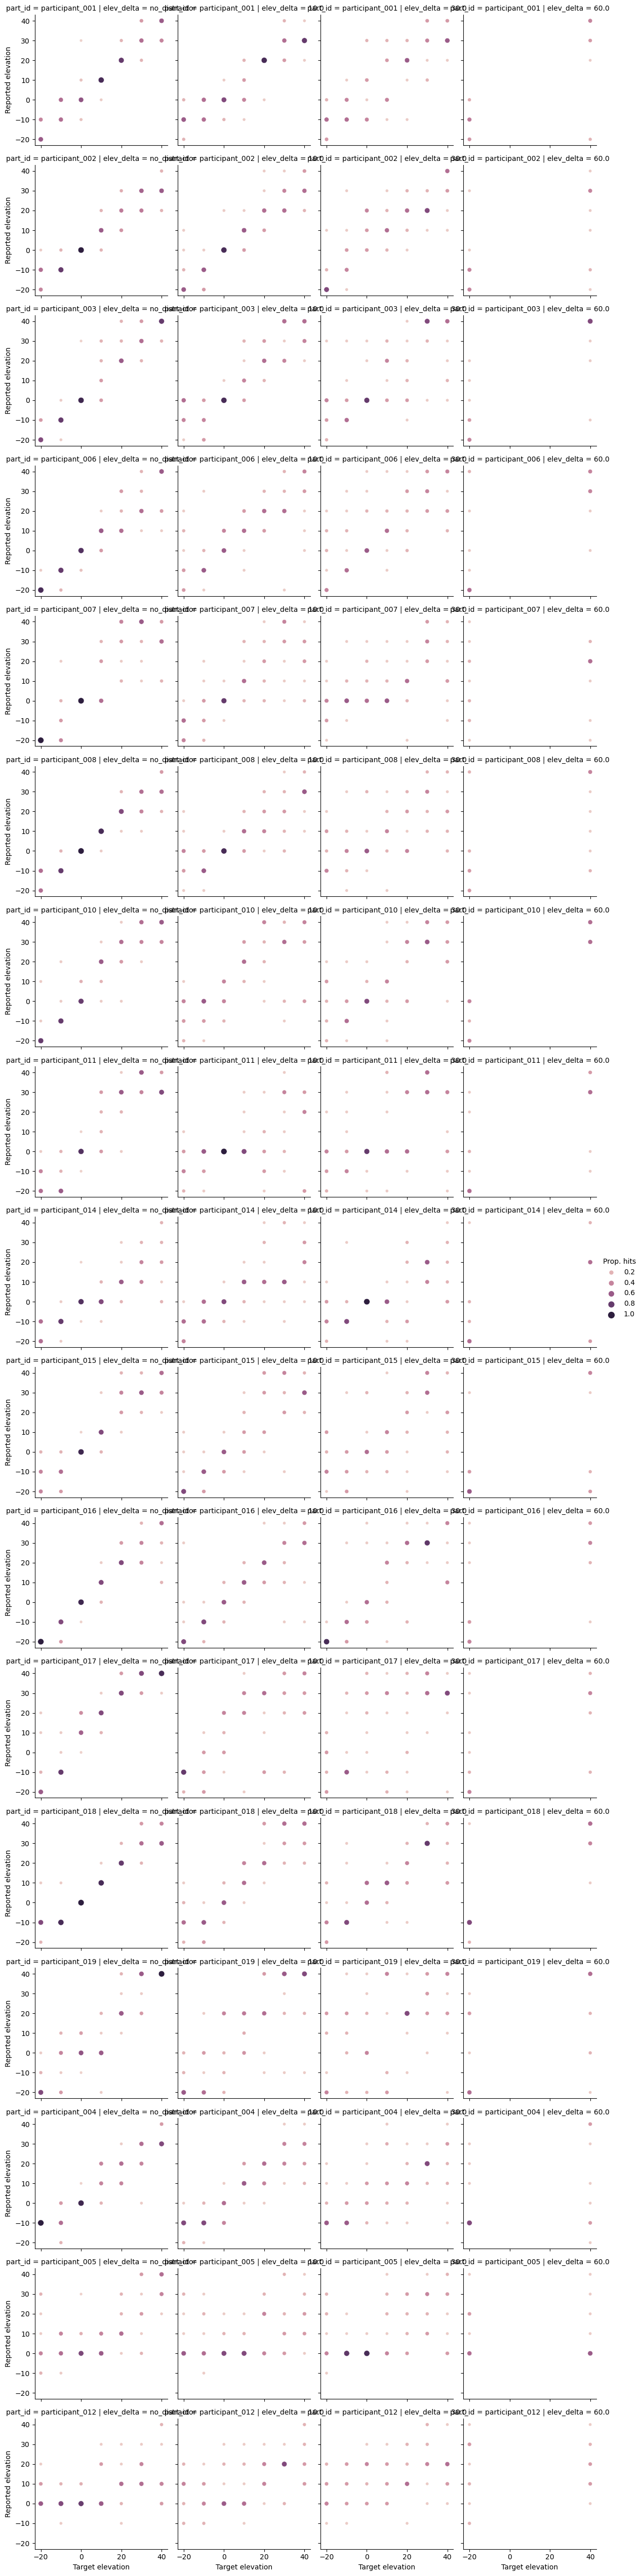

In [55]:
to_plot = results_df[(results_df.target_azimuth==0) & (results_df.azim_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_elevation', 'elev_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_elevation.unique():
    for dist_cond in to_plot.elev_delta.unique():
        for part_id in to_plot.part_id.unique():
            elev_cond_ix = (to_plot.target_elevation == true_elev) & (to_plot.elev_delta == dist_cond) & (to_plot.part_id == part_id)
            elev_cond_trials = to_plot[elev_cond_ix]
            total_trials = elev_cond_trials.response.sum()
            to_plot.loc[elev_cond_ix, 'prop_hits'] = elev_cond_trials['response'].div(total_trials)

fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_elevation', y='pred_elevation',
                     hue='prop_hits', size='prop_hits',
                     col='elev_delta',
                    row='part_id',

                     height=3, aspect=1,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.legend.set_title('Prop. hits')
g.set(xlabel='Target elevation', ylabel='Reported elevation')




In [83]:
results_df.part_id.value_counts().sort_index()

part_id
participant_001    532
participant_002    532
participant_003    533
participant_004    532
participant_005    535
participant_006    534
participant_007    534
participant_008    534
participant_010    534
participant_011    534
participant_012    534
participant_014    534
participant_015    534
participant_016    536
participant_017    534
participant_018    534
participant_019    533
Name: count, dtype: int64

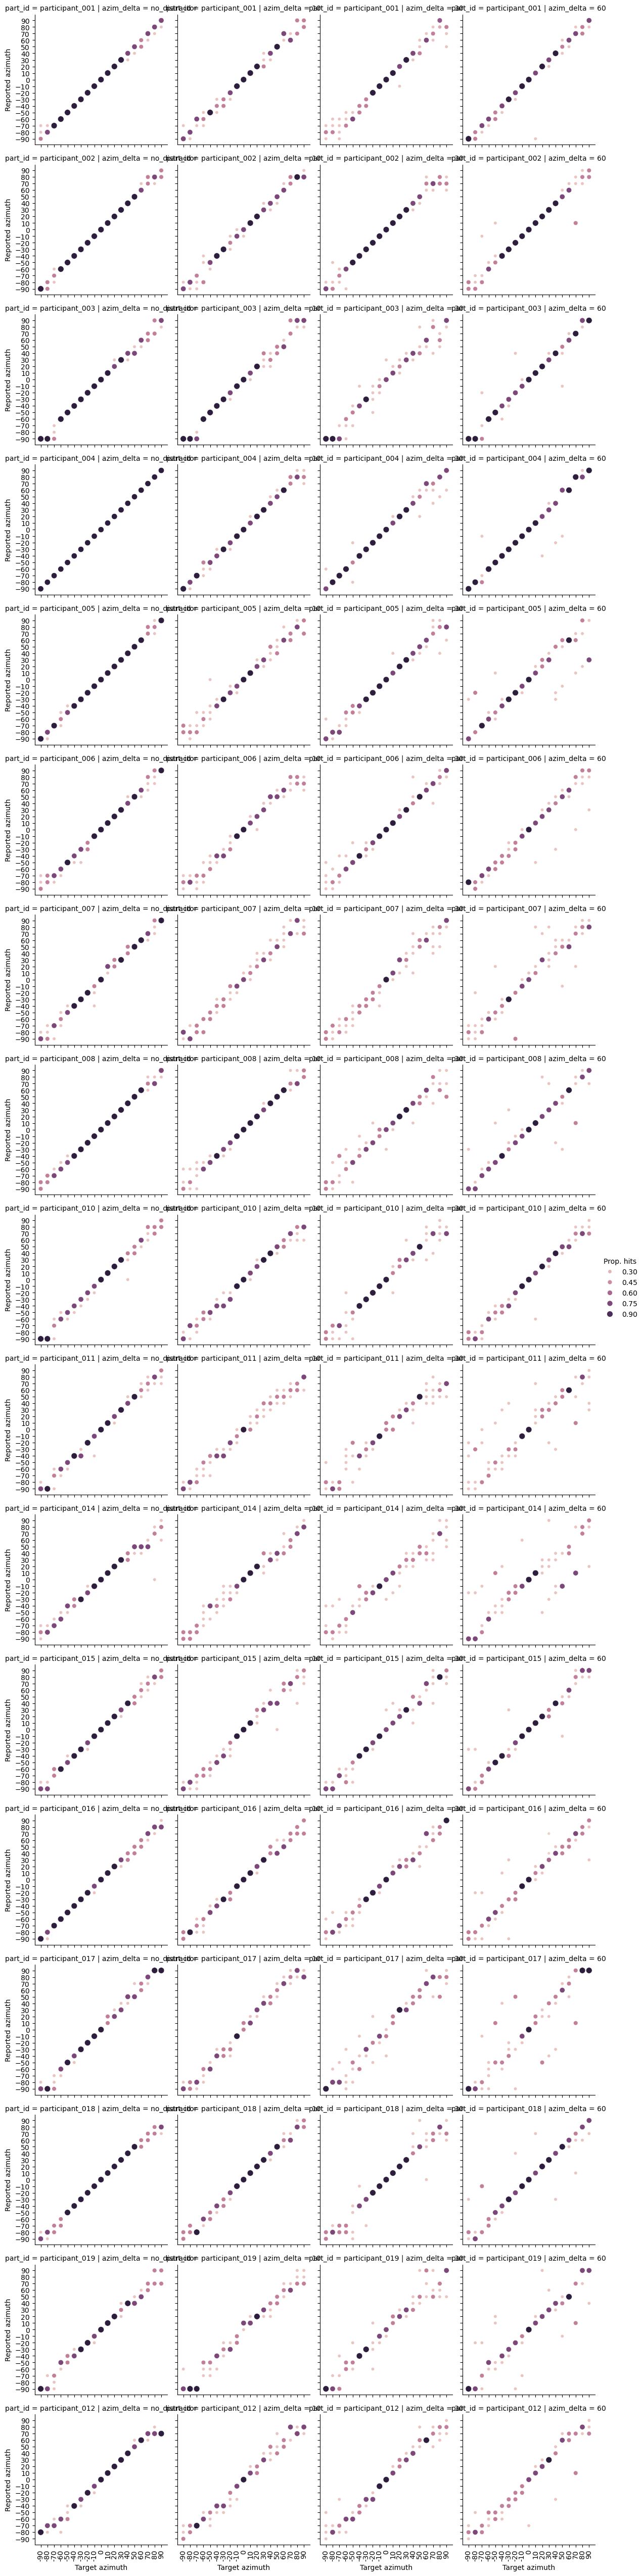

In [37]:
to_plot = results_df[(results_df.target_elevation ==0) & (results_df.elev_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_azimuth', 'azim_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_azimuth.unique():
    for dist_cond in to_plot.azim_delta.unique():
        for part_id in to_plot.part_id.unique():
            azim_cond_ix = (to_plot.target_azimuth == true_elev) & (to_plot.azim_delta == dist_cond) & (to_plot.part_id == part_id)
            azim_cond_trials = to_plot[azim_cond_ix]
            total_trials = azim_cond_trials.response.sum()
            to_plot.loc[azim_cond_ix, 'prop_hits'] = azim_cond_trials['response'].div(total_trials)


fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_azimuth', y='pred_azimuth',
                     hue='prop_hits', size='prop_hits',
                     col='azim_delta',
                     row='part_id',
                     height=3,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.legend.set_title('Prop. hits')
g.set(xlabel='Target azimuth', ylabel='Reported azimuth', xticks=np.arange(-90, 91, 10), yticks=np.arange(-90, 91, 10))
g.set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)




In [84]:
### Get mean absolute error 
results_df['azim_error'] =  np.abs(results_df['target_azimuth'] - results_df['pred_azimuth'])
results_df['elev_error'] =  np.abs(results_df['target_elevation'] - results_df['pred_elevation']) 

/tmp/ipykernel_1919330/1407566295.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)


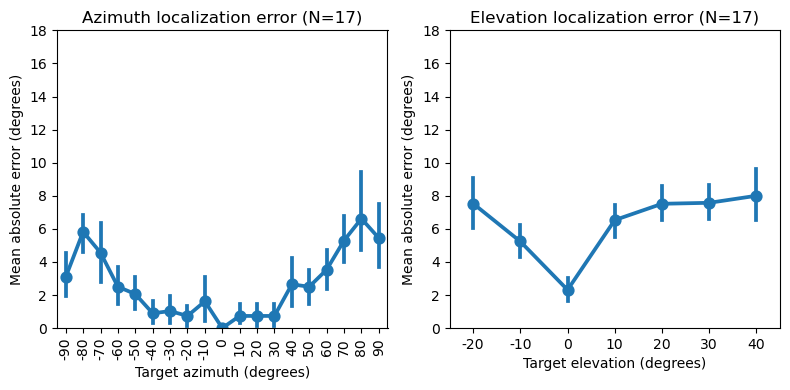

In [85]:
## Plot mean abs localization error
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
to_plot = results_df[(results_df.elev_delta.isin(['no_distractor'])) & (results_df.azim_delta.isin(['no_distractor']))].copy()
N = to_plot.part_id.nunique()
sns.pointplot(data=to_plot[to_plot.target_elevation == 0], x='target_azimuth', y='azim_error', ax=axs[0])
sns.pointplot(data=to_plot[to_plot.target_azimuth == 0], x='target_elevation', y='elev_error', ax=axs[1])
axs[0].set_ylabel('Mean absolute error (degrees)')
axs[1].set_ylabel('Mean absolute error (degrees)')
axs[0].set_xlabel('Target azimuth (degrees)')
axs[0].set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)
axs[1].set_xlabel('Target elevation (degrees)')

axs[0].set_title(f'Azimuth localization error (N={N})')
axs[1].set_title(f'Elevation localization error (N={N})')
for ax in axs:
    ax.set_ylim(0, 18)
plt.tight_layout()


In [86]:
group_mean_azim_error = to_plot[to_plot.target_elevation == 0].azim_error.mean()
group_mean_elev_error = to_plot[to_plot.target_azimuth == 0].elev_error.mean()


In [106]:

# remove bias per participant per elevation
for part_id in results_df.part_id.unique():
    for elev in results_df.target_elevation.unique():
        elev_ix = (results_df.part_id == part_id) & (results_df.target_elevation == elev) & (results_df.distractor_cond == 'no distractor') & (results_df.target_azimuth == 0)
        all_elev_trial_ixs = (results_df.part_id == part_id) & (results_df.target_elevation == elev) &  (results_df.target_azimuth == 0)
        # get participant elevation bias
        elev_bias = results_df.loc[elev_ix, 'pred_elevation'].mean() 
        results_df.loc[all_elev_trial_ixs, 'error_rel_elev_resp_bias'] = np.abs(results_df.loc[all_elev_trial_ixs, 'pred_elevation'] - elev_bias)
        results_df.loc[all_elev_trial_ixs, 'error_rel_resp_bias'] = np.abs(results_df.loc[all_elev_trial_ixs, 'pred_elevation'] - elev_bias)
        results_df.loc[all_elev_trial_ixs, 'offset_condition'] = 'elevation'
        # print(part_id, elev, elev_bias)

    # same for azimuth 
    for azim in results_df.target_azimuth.unique():
        azim_ix = (results_df.part_id == part_id) & (results_df.target_azimuth == azim) & (results_df.distractor_cond == 'no distractor') & (results_df.target_elevation == 0)
        all_azim_trial_ixs = (results_df.part_id == part_id) & (results_df.target_azimuth == azim) & (results_df.target_elevation == 0)
        # get participant azimuth bias, defined as their average error in the no distractor condition
        azim_bias =  results_df.loc[azim_ix, 'pred_azimuth'].mean()
        # print(part_id, azim, azim_bias)
        results_df.loc[all_azim_trial_ixs, 'error_rel_azim_resp_bias'] = np.abs(results_df.loc[all_azim_trial_ixs, 'pred_azimuth'] - azim_bias)
        results_df.loc[all_azim_trial_ixs, 'error_rel_resp_bias'] = np.abs(results_df.loc[all_azim_trial_ixs, 'pred_azimuth'] - azim_bias)
        results_df.loc[all_azim_trial_ixs, 'offset_condition'] = 'azimuth'



In [107]:
results_df

,trial_num,locations,response,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_speaker_label,distractor_speaker_label,...,Unnamed: 0,gt_info,true_loc,distractor_cond,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias,error_rel_resp_bias,offset_condition
0,17,"[[[0, 0], [0, 0]]]",e10,"(0, 0)",None,no_distractor,no_distractor,0,E10,None,...,NaN,NaN,NaN,no distractor,0,0,2.142857,0.0,0.0,azimuth
1,18,"[[[0, 0], [-80, 0]]]",e2,"(-80, 0)","(-50, 0)",30,0.0,0,E2,E5,...,NaN,NaN,NaN,with distractor,0,0,2.142857,2.5,2.5,azimuth
2,19,"[[[0, 0], [-90, 0]]]",e3,"(-90, 0)","(-60, 0)",30,0.0,0,E1,E4,...,NaN,NaN,NaN,with distractor,20,0,2.142857,12.5,12.5,azimuth
3,20,"[[[0, 0], [-90, 0]]]",e2,"(-90, 0)","(-60, 0)",30,0.0,0,E1,E4,...,NaN,NaN,NaN,with distractor,10,0,2.142857,2.5,2.5,azimuth
4,21,"[[[0, 0], [0, 0]]]",e10,"(0, 0)",None,no_distractor,no_distractor,0,E10,None,...,NaN,NaN,NaN,no distractor,0,0,2.142857,0.0,0.0,azimuth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9068,529,NaN,E14,"(40, 0)",None,no_distractor,no_distractor,0,E14,None,...,83.0,"([(0, 0), (40, 0)], None, 0, [PosixPath('/User...",E14,no distractor,0,0,2.142857,0.0,0.0,azimuth
9069,530,NaN,E7,"(-30, 0)","(-40, 0)",10,0.0,0,E7,E6,...,84.0,"([(0, 0), (-30, 0)], (-40, 0), 0, [PosixPath('...",E7,with distractor,0,0,2.142857,0.0,0.0,azimuth
9070,531,NaN,E5,"(-50, 0)","(10, 0)",60,0.0,0,E5,E11,...,85.0,"([(0, 0), (-50, 0)], (10, 0), 0, [PosixPath('/...",E5,with distractor,0,0,2.142857,5.0,5.0,azimuth
9071,532,NaN,G10,"(0, -20)","(0, -10)",0,10.0,0,G10,F10,...,86.0,"([(0, 0), (0, -20)], (0, -10), 0, [PosixPath('...",G10,with distractor,0,0,4.000000,0.0,4.0,elevation


In [121]:
## Group by participant 

summary_df = results_df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta', 'sex_cond', 'offset_condition']).agg({'azim_error': 'mean',
                                                                                                                                       'elev_error': 'mean',
                                                                                                                                       'error_rel_elev_resp_bias':'mean',
                                                                                                                                       'error_rel_azim_resp_bias':'mean',
                                                                                                                                       'error_rel_resp_bias': 'mean'}).reset_index()
# flatten columns
# summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
# # remve _ in the end of each column name
# summary_df.columns = [col[:-1] if col[-1] == '_' else col for col in summary_df.columns]
summary_df

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,offset_condition,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias,error_rel_resp_bias
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,azimuth,7.500000,0.000000,2.142857,7.500000,7.500000
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,azimuth,3.333333,0.000000,2.142857,4.166667,4.166667
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,azimuth,0.000000,0.000000,2.142857,2.500000,2.500000
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,azimuth,0.000000,0.000000,2.142857,0.000000,0.000000
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,azimuth,0.000000,0.000000,2.142857,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,participant_019,with distractor,90,0,10,0.0,same,azimuth,16.666667,10.000000,12.142857,6.666667,6.666667
3164,participant_019,with distractor,90,0,30,0.0,different,azimuth,0.000000,10.000000,12.142857,10.000000,10.000000
3165,participant_019,with distractor,90,0,30,0.0,same,azimuth,20.000000,10.000000,12.142857,20.000000,20.000000
3166,participant_019,with distractor,90,0,60,0.0,different,azimuth,0.000000,0.000000,2.142857,10.000000,10.000000


In [111]:
summary_df.offset_condition.unique()

array(['azimuth', 'elevation'], dtype=object)

In [122]:
summary_df['elev_delta'] = summary_df['elev_delta'].astype('category')
summary_df['azim_delta'] = summary_df['azim_delta'].astype('category')

summary_df['elev_delta'] = [int(delta) if delta != 'no_distractor' else delta for delta in summary_df['elev_delta']]

summary_df.loc[summary_df['offset_condition'] == 'elevation', 'dist_offset'] = summary_df.loc[summary_df['offset_condition'] == 'elevation', 'elev_delta']
summary_df.loc[summary_df['offset_condition'] == 'azimuth', 'dist_offset'] = summary_df.loc[summary_df['offset_condition'] == 'azimuth', 'azim_delta']

In [123]:
summary_df

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,offset_condition,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias,error_rel_resp_bias,dist_offset
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,azimuth,7.500000,0.000000,2.142857,7.500000,7.500000,no_distractor
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,azimuth,3.333333,0.000000,2.142857,4.166667,4.166667,no_distractor
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,azimuth,0.000000,0.000000,2.142857,2.500000,2.500000,no_distractor
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,azimuth,0.000000,0.000000,2.142857,0.000000,0.000000,no_distractor
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,azimuth,0.000000,0.000000,2.142857,0.000000,0.000000,no_distractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,participant_019,with distractor,90,0,10,0,same,azimuth,16.666667,10.000000,12.142857,6.666667,6.666667,10
3164,participant_019,with distractor,90,0,30,0,different,azimuth,0.000000,10.000000,12.142857,10.000000,10.000000,30
3165,participant_019,with distractor,90,0,30,0,same,azimuth,20.000000,10.000000,12.142857,20.000000,20.000000,30
3166,participant_019,with distractor,90,0,60,0,different,azimuth,0.000000,0.000000,2.142857,10.000000,10.000000,60


/tmp/ipykernel_1919330/623848331.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


Text(0.5, 1.0, 'N=17')

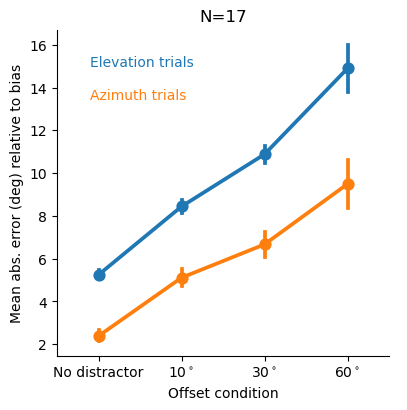

In [124]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]
order = ['no_distractor', 10, 30, 60]
N = summary_df.part_id.nunique()
g = sns.catplot(data=elev_to_plot,
                order=order,    
             x='elev_delta', y='error_rel_elev_resp_bias',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
              order=order,
             x='azim_delta', y='error_rel_azim_resp_bias',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
plt.title(f'N={N}')


/tmp/ipykernel_1919330/1675501698.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1919330/1675501698.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


Text(0.5, 1.05, 'All participants (N=17)')

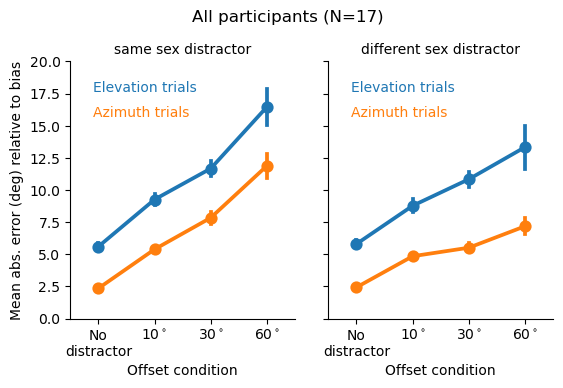

In [154]:
### Same plot but using grouped data 


order = ['no_distractor', 10, 30, 60]
hue_order = ['elevation', 'azimuth']
N = summary_df.part_id.nunique()
g = sns.catplot(data=summary_df,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            col='sex_cond', col_order=['same', 'different'],
            hue='offset_condition', hue_order=hue_order,   
            #  col='part_id',
            errorbar='se',# errstyle='bars', col
            legend=False,
            kind='point', height=3.5, aspect=.8)

g.set_titles("{col_name} sex distractor")
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
for ax in g.axes.flatten():
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
plt.suptitle(f"All participants (N={N})", y=1.05)
# g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
# g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
# plt.title(f'N={N}')


###

/tmp/ipykernel_1919330/1565593675.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  to_plot = azim_to_plot.groupby(['part_id', 'azim_delta']).error_rel_azim_resp_bias.mean().reset_index()


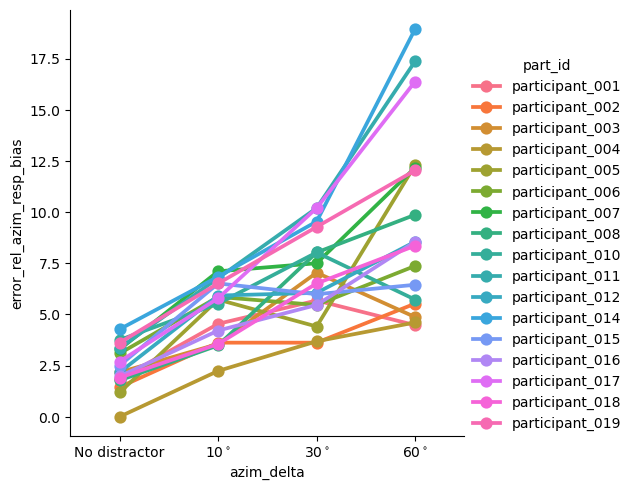

In [92]:
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]
to_plot = azim_to_plot.groupby(['part_id', 'azim_delta']).error_rel_azim_resp_bias.mean().reset_index()

order = ['no_distractor', 10, 30, 60]
g = sns.catplot(data=to_plot,
            kind='point',
             x='azim_delta', y='error_rel_azim_resp_bias',
             order=order,
            #  col='part_id',
            hue='part_id',
             errorbar='se',# errstyle='bars', col
            #   kind='point',
                # height=4, aspect=1
                )

g.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
#

In [93]:
to_plot

,part_id,azim_delta,error_rel_azim_resp_bias
0,participant_001,0,NaN
1,participant_001,10,4.539474
2,participant_001,30,5.679825
3,participant_001,60,4.473684
4,participant_001,no_distractor,1.842105
...,...,...,...
80,participant_019,0,NaN
81,participant_019,10,6.513158
82,participant_019,30,9.276316
83,participant_019,60,12.039474


/tmp/ipykernel_1919330/2655960456.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


[Text(0, 0, 'No distractor'),
 Text(1, 0, '10$^\\circ$'),
 Text(2, 0, '30$^\\circ$'),
 Text(3, 0, '60$^\\circ$')]

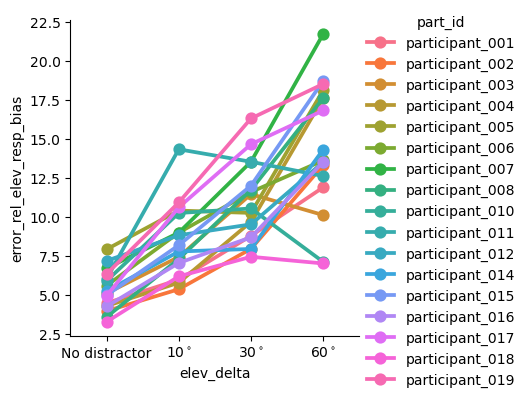

In [95]:
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
to_plot = elev_to_plot.groupby(['part_id', 'elev_delta']).error_rel_elev_resp_bias.mean().reset_index()

order = ['no_distractor', 10, 30, 60]
g = sns.catplot(data=to_plot,
             x='elev_delta', y='error_rel_elev_resp_bias',
             order=order,
            #  col='part_id',
            hue='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)

g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
#

/tmp/ipykernel_1919330/623848331.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


Text(0.5, 1.0, 'N=17')

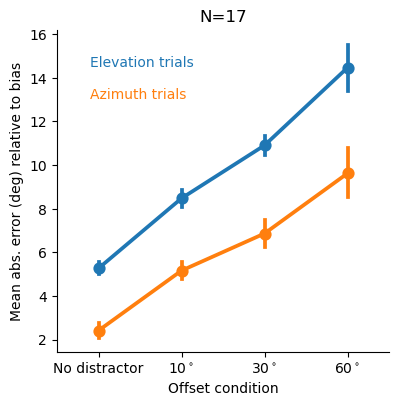

In [96]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]
order = ['no_distractor', 10, 30, 60]
N = summary_df.part_id.nunique()
g = sns.catplot(data=elev_to_plot,
                order=order,    
             x='elev_delta', y='error_rel_elev_resp_bias',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
              order=order,
             x='azim_delta', y='error_rel_azim_resp_bias',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
plt.title(f'N={N}')


# Split based on sex condition

In [99]:
## Group by participant 

summary_df = results_df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta', 'sex_cond']).agg({'azim_error': 'mean',
                                                                                                                                       'elev_error': 'mean',
                                                                                                                                       'error_rel_elev_resp_bias':'mean',
                                                                                                                                       'error_rel_azim_resp_bias':'mean'}).reset_index()
# flatten columns
# summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
# # remve _ in the end of each column name
# summary_df.columns = [col[:-1] if col[-1] == '_' else col for col in summary_df.columns]
summary_df['elev_delta'] = summary_df['elev_delta'].astype('category')
summary_df['azim_delta'] = summary_df['azim_delta'].astype('category')

summary_df['elev_delta'] = [int(delta) if delta != 'no_distractor' else delta for delta in summary_df['elev_delta']]

summary_df

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,7.500000,0.000000,2.142857,7.500000
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,3.333333,0.000000,2.142857,4.166667
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,0.000000,0.000000,2.142857,2.500000
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,0.000000,0.000000,2.142857,0.000000
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,0.000000,0.000000,2.142857,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
3163,participant_019,with distractor,90,0,10,0,same,16.666667,10.000000,12.142857,6.666667
3164,participant_019,with distractor,90,0,30,0,different,0.000000,10.000000,12.142857,10.000000
3165,participant_019,with distractor,90,0,30,0,same,20.000000,10.000000,12.142857,20.000000
3166,participant_019,with distractor,90,0,60,0,different,0.000000,0.000000,2.142857,10.000000


/tmp/ipykernel_1919330/2265653510.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1919330/2265653510.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


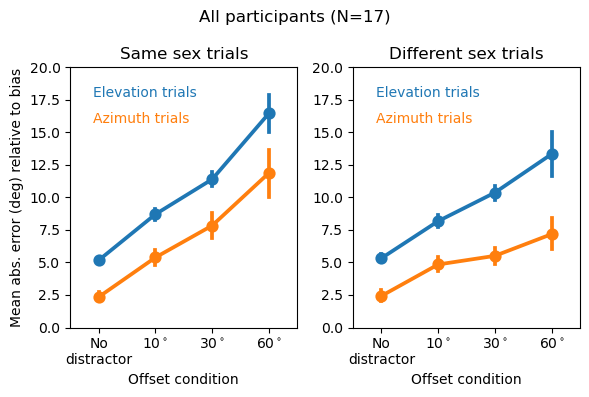

In [100]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]
N = summary_df.part_id.nunique()

sex_conds = ['same', 'different']
order = ['no_distractor', 10, 30, 60]

fig, axs = plt.subplots(1, 2, figsize=(6, 4))

for ix, sex_cond in enumerate(sex_conds):
    ax = axs[ix]
    sns.pointplot(data=elev_to_plot[elev_to_plot.sex_cond == sex_cond],
                    order=order,    
                x='elev_delta', y='error_rel_elev_resp_bias',
                #  col='part_id',
                errorbar='se',# errstyle='bars', col
                # kind='point', 
                # height=4, 
                # aspect=1,
                # markers='.',
                ax=ax)
    sns.pointplot(data=azim_to_plot[azim_to_plot.sex_cond == sex_cond],
                order=order,
                x='azim_delta', y='error_rel_azim_resp_bias',
                color='tab:orange',
                # markers='.',

                ax=ax)
    if ix == 0:
        ax.set_ylabel('Mean abs. error (deg) relative to bias')
    else:
        ax.set_ylabel('')
    ax.set(xlabel='Offset condition')
    # g.legend().remove()
    # add legend with correct colors

    ## Add text to indicate conditions
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

    # update xticks
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_title(f'{sex_cond.title()} sex trials')
    ax.set_ylim(0,20)
plt.suptitle(f"All participants (N={N})")
plt.tight_layout()
# (N={N})

In [101]:
summary_df

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,7.500000,0.000000,2.142857,7.500000
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,3.333333,0.000000,2.142857,4.166667
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,0.000000,0.000000,2.142857,2.500000
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,0.000000,0.000000,2.142857,0.000000
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,0.000000,0.000000,2.142857,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
3163,participant_019,with distractor,90,0,10,0,same,16.666667,10.000000,12.142857,6.666667
3164,participant_019,with distractor,90,0,30,0,different,0.000000,10.000000,12.142857,10.000000
3165,participant_019,with distractor,90,0,30,0,same,20.000000,10.000000,12.142857,20.000000
3166,participant_019,with distractor,90,0,60,0,different,0.000000,0.000000,2.142857,10.000000


In [ ]:
## Melt results for anova 

anova_df = summary_df.melt(id_vars=['part_id', 'sex_cond', "error_rel_elev_resp_bias", )

In [ ]:
### Run repeated measures anova on different sex trials 

import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM


## Filter participants based on performance 

In [22]:
results_df['accuracy'] = (results_df['response'].str.upper() == results_df['target_speaker_label']).astype('int')

no_distractor = results_df[results_df.distractor_cond == 'no distractor'].copy()
# use first half of trials to get participant accuracy
part_acc_dict = {}
trials_to_exclude = []
for part_id in no_distractor.part_id.unique():
    part_total_trials = 0 
    part_running_acc = 0 
    part_trials = no_distractor[no_distractor.part_id == part_id]
    n_trials_per_location = part_trials["target_speaker_label"].value_counts()
    for location, n_trials in n_trials_per_location.items():
        trials_for_acc = part_trials[part_trials["target_speaker_label"] == location].head(n_trials)
        trials_to_exclude.append(trials_for_acc.index.values)
        part_total_trials += n_trials
        part_running_acc += trials_for_acc.accuracy.sum()
    part_acc_dict[part_id] = part_running_acc / part_total_trials

trials_to_exclude = np.concatenate(trials_to_exclude)


/tmp/ipykernel_1848668/1694026130.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1848668/1694026130.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1848668/1694026130.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1848668/1694026130.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\c

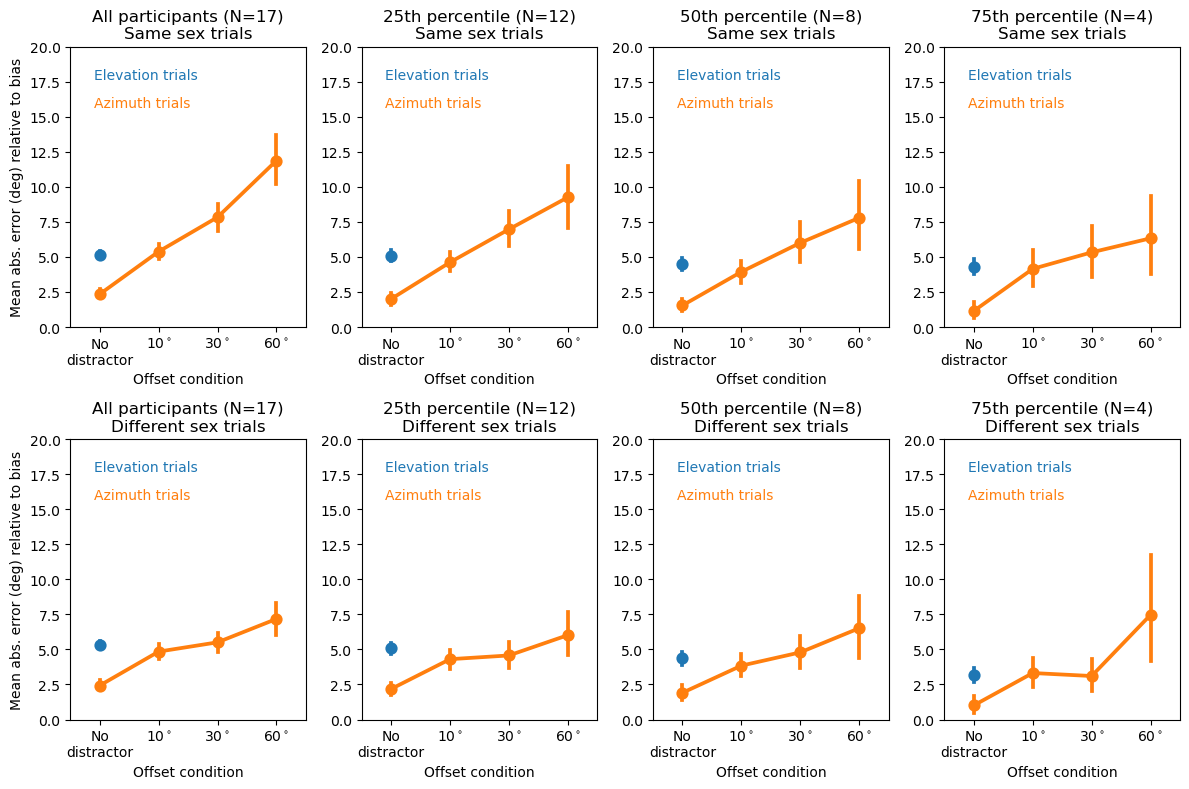

In [23]:
fig, axs = plt.subplots(2, 4, figsize=(12, 8))

ptile_values = [0, 25, 50, 75]

for ix, ptile_value in enumerate(ptile_values): 
    if ix > 0:
        ptile_cutoff = np.percentile(list(part_acc_dict.values()), ptile_value)
        good_participants = [participant_name for participant_name, part_acc in part_acc_dict.items() if part_acc > ptile_cutoff]
        to_plot = summary_df[summary_df.part_id.isin(good_participants)]
        to_plot = to_plot[~to_plot.index.isin(trials_to_exclude)]
    else:
        to_plot = summary_df
    N = to_plot.part_id.nunique()

    elev_to_plot = to_plot[(to_plot.target_azimuth == 0) & (to_plot.elev_delta!=0) ]
    azim_to_plot = to_plot[(to_plot.target_elevation == 0) & (to_plot.azim_delta!=0) ]
    order = ['no_distractor', 10, 30, 60]
    for jx, sex_cond in enumerate(sex_conds):
        ax = axs[jx, ix]
        sns.pointplot(data=elev_to_plot[elev_to_plot.sex_cond == sex_cond],
                        order=order,    
                    x='elev_delta', y='error_rel_elev_resp_bias',
                    #  col='part_id',
                    errorbar='se',# errstyle='bars', col
                    # kind='point', 
                    # height=4, 
                    # aspect=1,
                    # markers='.',
                    ax=ax)
        sns.pointplot(data=azim_to_plot[azim_to_plot.sex_cond == sex_cond],
                    order=order,
                    x='azim_delta', y='error_rel_azim_resp_bias',
                    color='tab:orange',
                    # markers='.',

                    ax=ax)
        if ix == 0:
            ax.set_ylabel('Mean abs. error (deg) relative to bias')
        else:
            ax.set_ylabel('')
        ax.set(xlabel='Offset condition')
        # g.legend().remove()
        # add legend with correct colors

        ## Add text to indicate conditions
        ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
        ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

        # update xticks
        ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
        if ix == 0:
            ax.set_title(f'All participants (N={N})\n{sex_cond.title()} sex trials')
        else:
            ax.set_title(f'{ptile_value}th percentile (N={N})\n{sex_cond.title()} sex trials')
        ax.set_ylim(0,20)

plt.tight_layout()

### Old plot for ref, don't re-run 

[Text(0, 0, 'No distractor'),
 Text(1, 0, '10$^\\circ$'),
 Text(2, 0, '30$^\\circ$'),
 Text(3, 0, '60$^\\circ$')]

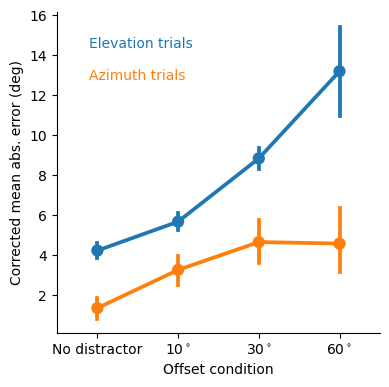

In [56]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

g = sns.catplot(data=elev_to_plot,
             x='elev_delta', y='scaled_elev_error_mean',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
             x='azim_delta', y='scaled_azim_error_mean',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Corrected mean abs. error (deg)')
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])



[Text(0.5, 25.722222222222214, 'Azimuth difference'),
 Text(510.3244949494949, 0.5, 'Corrected mean abs. error (deg)'),
 (-1.0, 20.0)]

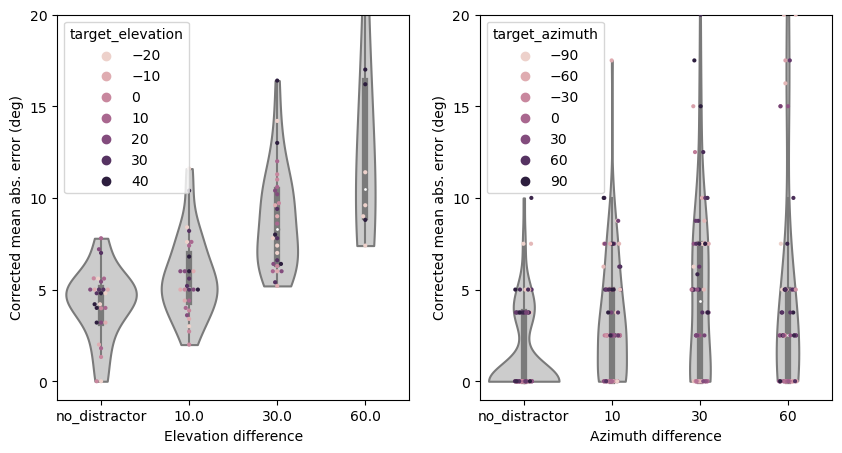

In [14]:
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

g = sns.violinplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", color = '0.8', cut=0, height=4, ax=axs[0])
sns.swarmplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", hue="target_elevation", size=3, ax=axs[0])

g.set(xlabel='Elevation difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[0].legend().remove() # set_title('Elevation difference')



g = sns.violinplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", color = '0.8',  cut=0, height=4, ax=axs[1])
sns.stripplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", hue="target_azimuth", size=3, ax=axs[1])
g.set(xlabel='Azimuth difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[1].legend().remove() # set_title('azimation difference')